In [1]:
import sys

%cd /Users/Kokiri/Documents/github/finance-data-pipeline
!{sys.executable} -m pytest tests -v

/Users/Kokiri/Documents/github/finance-data-pipeline
============================= test session starts ==============================
platform darwin -- Python 3.11.13, pytest-9.1.1, pluggy-1.6.0 -- /opt/homebrew/anaconda3/envs/finance-pipeline/bin/python
cachedir: .pytest_cache
rootdir: /Users/Kokiri/Documents/github/finance-data-pipeline
configfile: pyproject.toml
collected 44 items                                                             

tests/test_analysis.py::test_get_price_technicals_normal_case PASSED     [  2%]
tests/test_analysis.py::test_get_price_technicals_handles_empty_history PASSED [  4%]
tests/test_analysis.py::test_get_fundamentals_normal_case PASSED         [  6%]
tests/test_analysis.py::test_get_fundamentals_handles_missing_info PASSED [  9%]
tests/test_analysis.py::test_get_analyst_view_normal_case PASSED         [ 11%]
tests/test_analysis.py::test_get_analyst_view_handles_missing_info PASSED [ 13%]
tests/test_analysis.py::test_get_options_summary_normal_case P

In [8]:
import sys
sys.path.append('..')
import finance_data_pipeline as fp
import pandas as pd
import sqlite3

In [10]:
conn = sqlite3.connect('data/finance.db')
fp.init_db(conn)

In [15]:
fp.update_ticker_data(conn, "AAPL", "15m")

Fetching AAPL (15m)...


In [23]:
df = pd.read_sql_query(
    "SELECT * FROM price_history WHERE ticker = 'AAPL' and interval = '15m'", conn
)

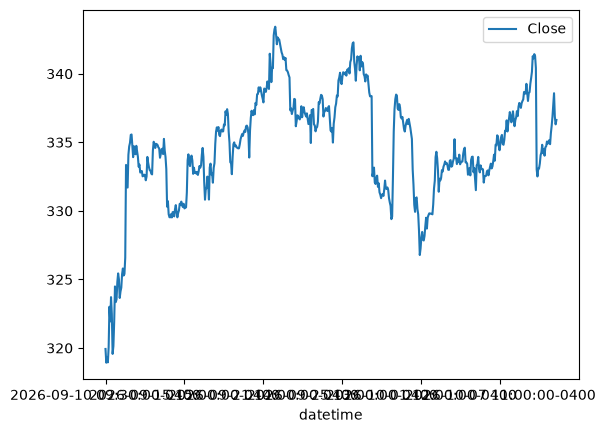

In [52]:
ax = df.plot(kind="line", x="datetime", y="Close")

In [21]:
AAPL_15m.head()

,ticker,interval,source,datetime,Open,High,Low,Close,Volume
0,AAPL,15m,yfinance,2026-09-10 09:30:00-0400,319.859985,323.128998,316.570007,319.929993,9486570
1,AAPL,15m,yfinance,2026-09-10 09:45:00-0400,319.954987,321.179993,317.839996,318.928986,2899854
2,AAPL,15m,yfinance,2026-09-10 10:00:00-0400,318.760010,320.000000,318.109985,319.339996,2171735
3,AAPL,15m,yfinance,2026-09-10 10:15:00-0400,319.333099,320.000000,318.751099,318.954987,1254885
4,AAPL,15m,yfinance,2026-09-10 10:30:00-0400,319.010010,320.850006,318.880005,320.065002,1636925
